In [ ]:
#NAHEEM'S CODE

In [ ]:
from metloom.pointdata import SnotelPointData
import geopandas as gpd
import os
import rioxarray as rxr
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import re

In [ ]:
sds

In [ ]:
##Create a dictionary of snow depth rasters where the keyword is the date and the item is the filepath

sd_dir = 'C:/Users/RDCRLSMC/Desktop/IDAHO_ALS/SNEX_MCS_Lidar/SD'
dir_25 = "C:/Users/RDCRLSMC/Desktop/IDAHO_ALS/2026"
raster_dict = {}
date_pattern = re.compile(r'\d{8}')
for root, dirs, files in os.walk(sd_dir):
    for filename in files:
        if date_pattern.search(filename):
            full_path = os.path.join(root, filename)
            split = filename.split('_')
            name = split[3]
            raster_dict[name] = os.path.abspath(full_path)

for root, dirs, files in os.walk(dir_25):
    for filename in files:
        if "MCS_clip" in filename:
            full_path = os.path.join(root, filename)
            result = filename.split("_")
            name = result[0]
            raster_dict[name] = os.path.abspath(full_path) 
        
print(raster_dict.keys())

In [ ]:
# Let's look at our old friend banner summit
pt = SnotelPointData("637:ID:SNTL", "MCS")
# request the data
df = pt.get_daily_data(datetime(2019, 10, 1), datetime(2026, 3, 30),
                                    [pt.ALLOWED_VARIABLES.SNOWDEPTH]).reset_index(level = [1])
df['SNOWDEPTH (m)'] = df['SNOWDEPTH'] * 0.0254
df.index = pd.to_datetime(df.index)

# Add the 'Date (MM-DD)' column
df['Date (MM-DD)'] = df.index.strftime('%m-%d')


df['WY'] = df.index.year + (df.index.month > 9).astype(int)

# Now, format the index to a string at the end
df.index = df.index.strftime('%Y-%m-%d')

In [ ]:
df.to_csv("snotel_data.csv") # save the data to a csv file


In [ ]:
## create a dataframe from the dictionary and make the date (keyword) a datetime object
sds = pd.DataFrame(raster_dict.items(), columns=['Filename', 'Filepath'])
sds['Date'] = pd.to_datetime(sds['Filename'], format='%Y%m%d')
sds['Date'] = sds['Date'].dt.strftime('%Y-%m-%d')

sds.set_index('Date', inplace=True)
sds = pd.concat([df, sds], axis=1, join='inner')


lidar_mean = []
lidar_std = []
lidar_median = []


for filename, raster in raster_dict.items():
        sd = rxr.open_rasterio(raster, masked = True)   
        date = pd.to_datetime(filename, format='%Y%m%d')
        lidar_mean.append(round(sd.mean().item(), 2))
        lidar_std.append(round(sd.std().item(), 2))
        lidar_median.append(round(sd.median().item(), 2))

        
    #add the lidar mean and std to the snotel dataframe
sds['LiDAR Mean (m)'] = lidar_mean
sds['LiDAR Std (m)'] = lidar_std
sds['Mean Difference (m)'] = sds['SNOWDEPTH (m)'] - sds['LiDAR Mean (m)']
sds['LiDAR Median (m)'] = lidar_median



In [ ]:
date = '19970326'
date_format = pd.to_datetime(date, format='%Y%m%d')
year = (date_format.strftime("%Y"))
year    

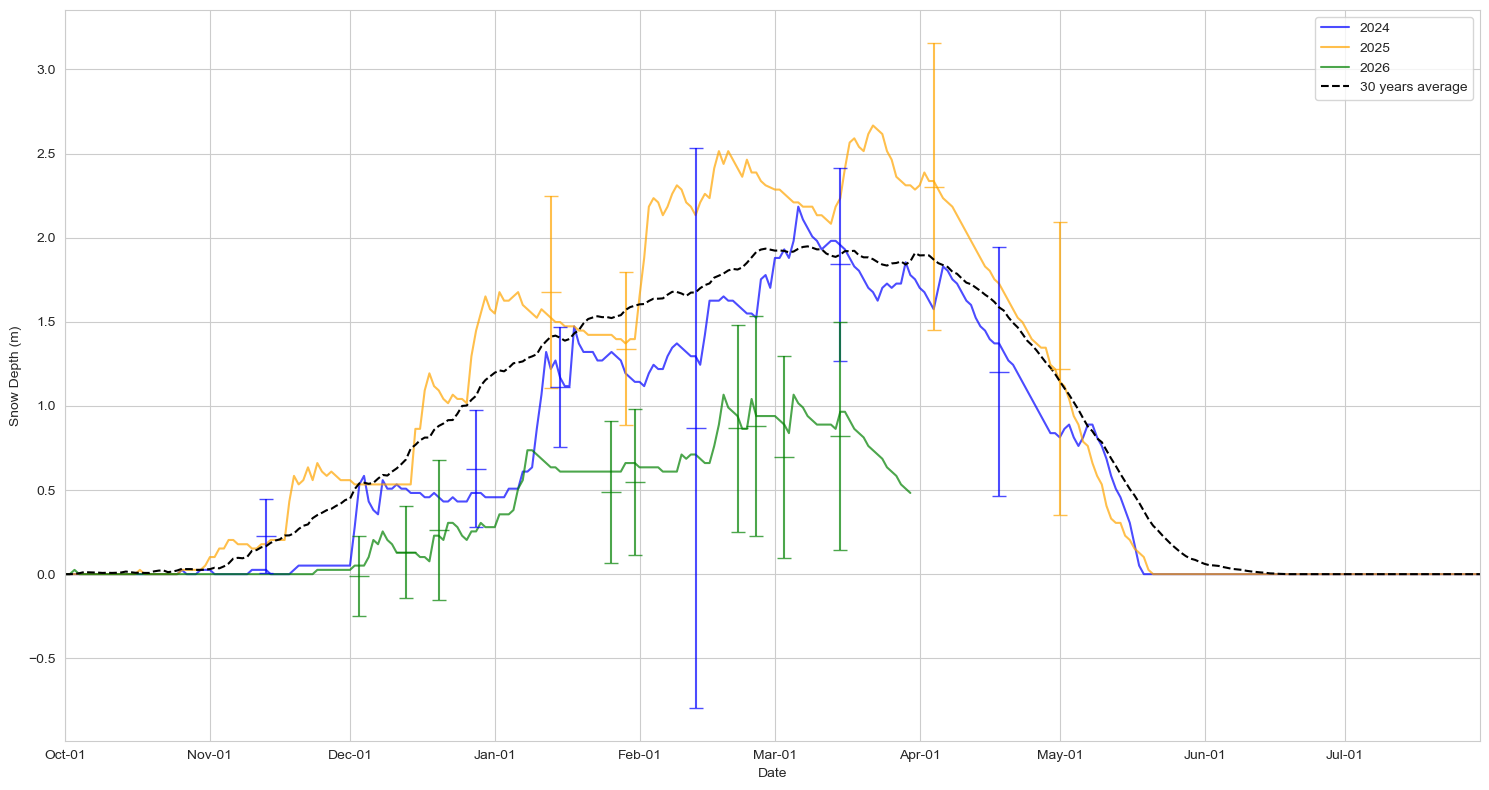

In [101]:
import matplotlib.colors as mcolors


start_year  = 2024
end_year = 2026

fig, ax = plt.subplots(figsize=(15, 8))
colors = {start_year: 'blue', start_year + 1: 'orange', start_year + 2: 'green', start_year + 3: 'red', start_year + 4: 'purple'}

for i in range(start_year-1, end_year):
        record = df[str(i) + '-10-01':str(i+1) + '-09-30']
        record.index = pd.to_datetime(record.index)
        record.index = record.index.strftime('%m-%d') #convert the datetime index to MM-DD so I can plot all the years
        ax.plot(record.index, record['SNOWDEPTH (m)'], label = i+1, color = colors[i+1], alpha = 0.7)

lidar_mean = []
lidar_std = []
for date, raster_path in raster_dict.items():
    sd = rxr.open_rasterio(raster_path, masked = True) 
    date = pd.to_datetime(date, format='%Y%m%d')
    year = date.strftime("%Y")
    month = date.strftime("%m")
    date_plot = date.strftime('%m-%d')
    if int(month) > 9:
            year = str(int(year) + 1)
    if int(year) >= start_year and int(year) <= end_year:
        ax.errorbar(x= date_plot , y=sd.mean(), yerr=sd.std(), marker='_', markersize =  15, capsize=5, color = colors[int(year)], alpha = 0.7)       
        lidar_mean.append(round(sd.mean().item(), 2))
        lidar_std.append(round(sd.std().item(), 2))

    # 
    # for filename, raster in raster_dict.items():
    #         sd = rxr.open_rasterio(raster, masked = True)   
    #         date = pd.to_datetime(filename, format='%Y%m%d')
    #         lidar_mean.append(round(sd.mean().item(), 2))
    #         lidar_std.append(round(sd.std().item(), 2))
    #         lidar_median.append(round(sd.median().item(), 2))
    
            
        #add the lidar mean and std to the snotel dataframe
    # sds['LiDAR Mean (m)'] = lidar_mean
    # sds['LiDAR Std (m)'] = lidar_std
    # sds['Mean Difference (m)'] = sds['SNOWDEPTH (m)'] - sds['LiDAR Mean (m)']
    # sds['LiDAR Median (m)'] = lidar_median



data_DDD = pt.get_daily_data(datetime(1993, 10, 1), datetime(2026, 3, 30),
                                       [pt.ALLOWED_VARIABLES.SNOWDEPTH]).reset_index(level = [1])
data_DDD['SNOWDEPTH (m)'] = data_DDD['SNOWDEPTH'] * 0.0254 #convert to meters
data_DDD.reset_index(inplace=True)
data_DDD['datetime'] = pd.to_datetime(data_DDD['datetime'])
data_DDD['day_of_year'] = data_DDD['datetime'].dt.dayofyear #add a new column (day_of_year) to the dataframe
data_DDD['year'] = data_DDD['datetime'].dt.year #add a new column (year) to the dataframe
daily_avg_snowdepth = data_DDD.groupby('day_of_year')['SNOWDEPTH (m)'].mean() #calculate the daily average snowdepth
daily_avg_snowdepth = daily_avg_snowdepth.reset_index() #reset the index
daily_avg_snowdepth['MM-DD'] = pd.to_datetime(daily_avg_snowdepth['day_of_year'], format='%j').dt.strftime('%m-%d') #add a new column (MM-DD) to the dataframe
daily_avg_snowdepth.set_index('MM-DD', inplace=True) #set the index to the YYYY-MM-DD column
#remove the last two rows (There is repetition of 01:01)
daily_avg_snowdepth = daily_avg_snowdepth[:-2]
#break the dataframe to two. Onw with records starting from 10-01 to 12-31 and the other from 01-01 to 09-30. Then combine them
daily_avg_snowdepth1 = daily_avg_snowdepth['10-01':'12-31']
daily_avg_snowdepth2 = daily_avg_snowdepth['01-01':'09-30']
daily_avg_snowdepth = pd.concat([daily_avg_snowdepth1, daily_avg_snowdepth2])
ax.plot(daily_avg_snowdepth.index, daily_avg_snowdepth['SNOWDEPTH (m)'], label='30 years average', linestyle='dashed', color='black')

    # Create major ticks for the first day of each month and minor ticks for the middle (day 15) of each month
major_ticks = daily_avg_snowdepth.reset_index()['MM-DD'][daily_avg_snowdepth.reset_index()['MM-DD'].str.endswith('-01')]
minor_ticks = daily_avg_snowdepth.reset_index()['MM-DD'][daily_avg_snowdepth.reset_index()['MM-DD'].str.endswith('-15')]
# Define a dictionary to map month numbers to their abbreviated names
month_map = {
    '10': 'Oct',
    '11': 'Nov',
    '12': 'Dec',
    '01': 'Jan',
    '02': 'Feb',
    '03': 'Mar',
    '04': 'Apr',
    '05': 'May',
    '06': 'Jun',
    '07': 'Jul',
    '08': 'Aug',
    '09': 'Sep'
}

# Create a new label format for the x-axis
new_labels = [month_map[date.split('-')[0]] + '-' + date.split('-')[1] for date in major_ticks]

# Set the major and minor ticks for the x-axis
plt.xticks(ticks = major_ticks, labels = new_labels)
plt.gca().set_xticks(minor_ticks, minor=True)

# # Display grid for both major and minor ticks
# plt.grid(which='both')
# plt.grid(which='both', alpha=0.2)

#set the xlimt
ax.set_xlim('10-01', '07-30')
# Add a legend
ax.legend()
#set axis label
ax.set_ylabel('Snow Depth (m)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()



In [ ]:
dates = df.index.get_level_values('datetime')
month = dates.month
mask = ((month >= 10) | (month <= 5))
df_filtered = df.loc[mask]
df_filtered.head()
df_filtered.to_csv("filtered_SNOTEL.csv")

In [ ]:
dates = df_filtered.index.get_level_values('datetime')
snowdepth = df_filtered['SNOWDEPTH (m)']

In [ ]:
LiDAR_dates = [
    '2020-02-09', '2021-03-15',  # added
    '2022-02-17', '2022-03-17', '2022-04-07',
    '2022-12-08', '2023-02-09', '2023-03-16',
    '2023-04-05', '2023-11-13', '2023-12-28',  # fixed 12-38 → 12-28
    '2024-01-15', '2024-02-13', '2024-03-15',
    '2024-04-28', '2025-01-25', '2025-01-29',
    '2025-04-04', '2025-05-01'
]

LiDAR_dates = pd.to_datetime(LiDAR_dates)

In [ ]:
dates

In [ ]:
    # Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dates, snowdepth, linestyle='-', label='Snow Depth')

for i, d in enumerate(LiDAR_dates):
        plt.axvline(
        d,
        color='red',
        linestyle='--',
        linewidth=1,
        label='LiDAR Survey' if i == 0 else None
    )

plt.xlabel('Date')
plt.ylabel('SNOWDEPTH (m)')
plt.title('Mores Creek SNOTEL')
plt.grid(True)
plt.legend()

# Optional: limit x-axis to 5 labels
# plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))

plt.show()


In [ ]:
path = 'filtered_SNOTEL.csv'
df = pd.read_csv(path)
df=df.assign(datetime = pd.to_datetime(df.datetime))
df = df[df['datetime'].dt.month.isin([10,11,12,1,2,3,4,5])]
df = df.sort_values('datetime').reset_index(drop=True)

##Do same for LiDAR dates

# Create a pseudo x-axis that skips summer months
pseudo_x = []
prev_date = None
offset = 0
for d in df['datetime']:
    if prev_date is not None and (d - prev_date).days > 120:  # gap > ~4 months
        offset += 120  # skip the summer
    pseudo_x.append((d - df['datetime'].iloc[0]).days - offset)
    prev_date = d
df['pseudo_x'] = pseudo_x
# Determine where each season (year) starts
year_starts = df.groupby(df['datetime'].dt.year)['pseudo_x'].min()
# Plot


plt.figure(figsize=(10,5))
plt.plot(df['pseudo_x'], df['SNOWDEPTH'], lw=1)
plt.xlabel("Seasonal Timeline (Oct–May)")
plt.ylabel("SNOWDEPTH")

# Label each year’s start on the x-axis
plt.xticks(year_starts, year_starts.index, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
dates = df.index.get_level_values('datetime')
start = pd.Timestamp('2022-10-01 08:00:00+00:00')
end   = pd.Timestamp('2023-05-30 08:00:00+00:00')

mask = (dates >= start) & (dates <= end)

WY2023 = df.loc[mask]

WY2023

In [ ]:
##'2022-12-08', '2023-02-09', '2023-03-16', 2023-11-13', '2023-12-28',  # fixed 12-38 → 12-28'2024-01-15', '2024-02-13', '2024-03-15', '2024-04-28',

dates = WY2023.index.get_level_values('datetime')
snowdepth = WY2023['SNOWDEPTH (m)']

Wy23 = fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(dates, snowdepth, label='Snow Depth')
ax.set_title("WY 23 MCS SNOTEL")
ax.set_ylabel("SWE (m)")

# Add vertical lines, label only once
vlines = [pd.Timestamp("2022-12-08"), pd.Timestamp("2023-02-09"), pd.Timestamp("2023-03-16"), pd.Timestamp("2023-04-15")]
for i, dt in enumerate(vlines):
    if i == 0:
        ax.axvline(dt, color="red", linestyle="--", linewidth=1, label='LiDAR')
    else:
        ax.axvline(dt, color="red", linestyle="--", linewidth=1)

ax.tick_params(axis='x', labelrotation=45)
ax.legend()
plt.show()


In [ ]:
dates = df.index.get_level_values('datetime')
start = pd.Timestamp('2023-10-01 08:00:00+00:00')
end   = pd.Timestamp('2024-05-30 08:00:00+00:00')

mask = (dates >= start) & (dates <= end)

WY2024 = df.loc[mask]

WY2024

In [ ]:
dates = WY2024.index.get_level_values('datetime')
snowdepth = WY2024['SNOWDEPTH (m)']

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(dates, snowdepth, label='Snow Depth')
ax.set_title("WY 24 MCS SNOTEL")
ax.set_ylabel("SWE (m)")

vlines = [
    pd.Timestamp("2023-12-28"),
    pd.Timestamp("2024-01-15"),
    pd.Timestamp("2024-02-13"),
    pd.Timestamp("2024-03-15"),
    pd.Timestamp("2024-04-28"),
]

for i, dt in enumerate(vlines):
    ax.axvline(
        dt,
        color="red",
        linestyle="--",
        linewidth=1,
        label="LiDAR" if i == 0 else None,
    )

ax.tick_params(axis='x', labelrotation=45)
ax.legend()
plt.tight_layout()
plt.show()
